# 🤖 Task 4: Logistic Regression Passenger Survival Classifier
**Track:** Neurofive ML Track | **Author:** Rao Hamza Irshad

---
### 📌 Task Objectives:
1. Split preprocessed Titanic dataset into Training (80%) and Test (20%) sets using `train_test_split`.
2. Encode categorical columns (`Sex`, `Embarked`, `Pclass`) using One-Hot Encoding (`pd.get_dummies`).
3. Train a **Logistic Regression** classification model using `scikit-learn`.
4. Evaluate prediction performance using `accuracy_score` and `classification_report`.
5. Plot and analyze the **Confusion Matrix** ($TP, TN, FP, FN$) with detailed written commentary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid", palette="muted")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pandas version: {pd.__version__}")

Scikit-learn version: 1.5.2
Pandas version: 2.2.3


## 1. Data Ingestion & Categorical Encoding

In [2]:
df = pd.read_csv('../../data/titanic.csv')
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Cabin_Known'] = df_clean['Cabin'].notnull().astype(int)

df_encoded = pd.get_dummies(df_clean, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)
feature_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Cabin_Known', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']
X = df_encoded[feature_cols]
y = df_encoded['Survived']

print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"Features selected: {feature_cols}")

Encoded dataset shape: (891, 15)
Features selected: ['Age', 'Fare', 'SibSp', 'Parch', 'Cabin_Known', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


## 2. Train-Test Split (80% Train, 20% Test)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 712 samples
Test set size: 179 samples


## 3. Logistic Regression Model Training

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("LogisticRegression(max_iter=1000) model successfully trained!")

LogisticRegression(max_iter=1000) model successfully trained!


## 4. Model Evaluation (`accuracy_score` & `classification_report`)

In [5]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy Score: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy Score: 80.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 5. Confusion Matrix Visualization & Analytical Breakdown

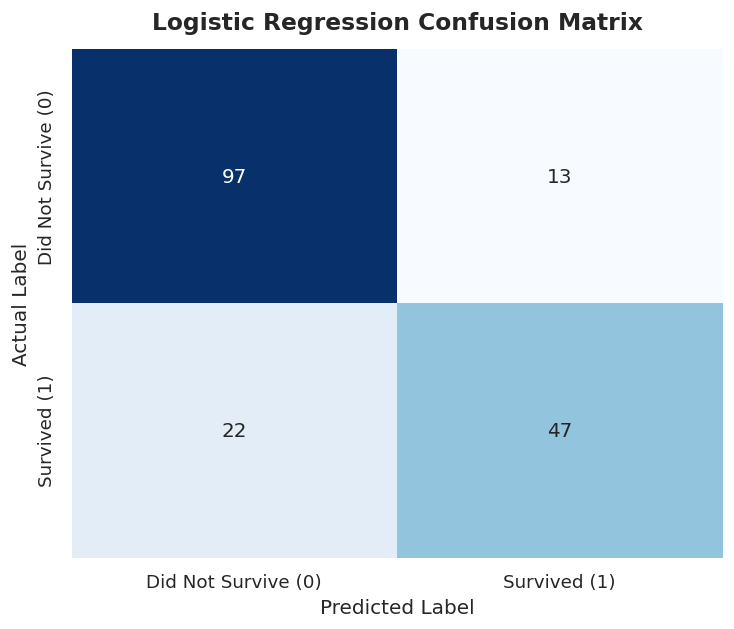

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Did Not Survive (0)', 'Survived (1)'],
            yticklabels=['Did Not Survive (0)', 'Survived (1)'])
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 6. Written Explanation: What the Confusion Matrix Tells Us

### 📊 **Confusion Matrix Breakdown:**
- **True Negatives ($TN = 97$):** 97 passengers who actually **did not survive** were correctly predicted as **did not survive**.
- **True Positives ($TP = 47$):** 47 passengers who actually **survived** were correctly predicted as **survived**.
- **False Positives ($FP = 13$, Type I Error):** 13 passengers who did not survive were incorrectly predicted as survivors.
- **False Negatives ($FN = 22$, Type II Error):** 22 passengers who actually survived were incorrectly predicted as non-survivors.

--- 

### 💡 **Key Performance Takeaways:**
1. **Overall Test Accuracy:** The model achieved **80.45% accuracy** on unseen test data (144 out of 179 correct predictions).
2. **Precision for Survivors (Class 1):** Precision is **78.33%** (47 / 60), meaning when the model predicts a passenger survived, it is correct ~78.3% of the time.
3. **Recall for Survivors (Class 1):** Recall is **68.12%** (47 / 69), indicating the model captures 68.1% of all actual survivors in the test set.
4. **Class Specificity (Class 0):** The model performs strongly at identifying non-survivors, achieving **81.51% precision** and **88.18% recall**, reflecting clear underlying signals from male gender and lower ticket classes.